<a href="https://colab.research.google.com/github/diipperss/DNN_GroupProject/blob/main/PartB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part B: Text Emotion Recognition


In [1]:
!pip install pandas numpy scikit-learn tensorflow matplotlib seaborn

In [1]:
import torch
print(torch.cuda.is_available())

True


In [5]:
from google.colab import files
uploaded = files.upload()

Saving text_emotion.csv to text_emotion.csv


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(list(uploaded.keys())[0])
df = df[['content','sentiment']].dropna()

le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

X_train, X_val, y_train, y_val = train_test_split(
    df['content'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42
)

In [7]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=64)
val_encodings = tokenizer(list(X_val), truncation=True, padding=True, max_length=64)

In [8]:
import torch

class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmotionDataset(train_encodings, y_train)
val_dataset = EmotionDataset(val_encodings, y_val)

In [9]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(le.classes_)
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

In [15]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,1.775268,1.785675
2,1.636867,1.788201
3,1.460791,1.848863


TrainOutput(global_step=6000, training_loss=1.6504499816894531, metrics={'train_runtime': 1252.4252, 'train_samples_per_second': 76.651, 'train_steps_per_second': 4.791, 'total_flos': 3157644496896000.0, 'train_loss': 1.6504499816894531, 'epoch': 3.0})

In [16]:
import numpy as np
from sklearn.metrics import accuracy_score

preds = trainer.predict(val_dataset)
y_pred = np.argmax(preds.predictions, axis=1)

acc = accuracy_score(y_val, y_pred)
print("Validation Accuracy:", acc)

Validation Accuracy: 0.38825


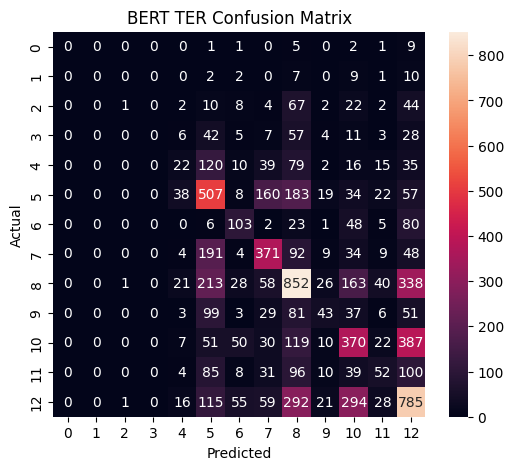

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("BERT TER Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    inputs = {key: val.to(device) for key, val in inputs.items()}
    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()
    return le.inverse_transform([pred])[0]

print(predict("Today i heard good news, found a new job!"))
print(predict("I am tired of studying. This is tiring and frustrating when the model can't predict correctly."))

happiness
worry
